In [165]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate

## 1.1

In [166]:
G=1
c=1
M=1
m1=0.5
m2=0.5

## 1.2

In [167]:
def f(t,y):
    #x1, vx1, y1, vy1, z1, vz1, x2, vx2, y2, vy2, z2, vz2 = y
    
    r1=np.array([y[0],y[2],y[4]])
    r2=np.array([y[6],y[8],y[10]])

    vec_r12=r1-r2
    r12=np.sqrt(np.dot(vec_r12,vec_r12))
    
    n12=vec_r12/r12

    v1=np.array([y[1],y[3],y[5]])
    v2=np.array([y[7],y[9],y[11]])

    vec_v12=v1-v2
    v12=np.sqrt(np.dot(vec_v12,vec_v12))

    nv12=vec_v12/v12

    #T1=(208*G**3*m1*m2**2) / (15*r12**4) *np.dot(n12,vec_v12)
    #T2=-(24*G**3*m1**2*m2) / (5*r12**4) *np.dot(n12,vec_v12)
    
    a1=-G*m2/r12**2*n12 + 1/c**5*( ( (208*G**3*m1*m2**2) / (15*r12**4) *np.dot(n12,vec_v12) - (24*G**3*m1**2*m2) / (5*r12**4) *np.dot(n12,vec_v12) + (12*G**2*m1*m2) / (5*r12**3) *np.dot(n12,vec_v12) *v12**2 ) *n12 + ( (8*G**3*m1**2*m2) / (5*r12**4) - (32*G**3*m1*m2**2) / (5*r12**4) - (4*G**2*m1*m2) / (5*r12**3) *v12**2) * vec_v12)

    n12=-n12
    v12=-v12
    vec_v12=-vec_v12

    a2=-G*m2/r12**2*n12 + 1/c**5*( ( (208*G**3*m1*m2**2) / (15*r12**4) *np.dot(n12,vec_v12) - (24*G**3*m1**2*m2) / (5*r12**4) *np.dot(n12,vec_v12) + (12*G**2*m1*m2) / (5*r12**3) *np.dot(n12,vec_v12) *v12**2 ) *n12 + ( (8*G**3*m1**2*m2) / (5*r12**4) - (32*G**3*m1*m2**2) / (5*r12**4) - (4*G**2*m1*m2) / (5*r12**3) *v12**2) * vec_v12)

    y_prime=np.array([v1[0],a1[0],v1[1],a1[1],v1[2],a1[2],v2[0],a2[0],v2[1],a2[1],v2[2],a2[2]])

    return y_prime

In [168]:
def isco(t,y):
    m=np.maximum(m1,m2)
    r12=np.sqrt((y[0]-y[6])**2+(y[2]-y[8])**2+(y[4]-y[10])**2)
    return r12-6*G*m/c**2

In [169]:
tf=12000

e=0.5
a=20
vy1=m2/M*np.sqrt(G*M/a*(1+e)/(1-e))
vy2=m1/M*np.sqrt(G*M/a*(1+e)/(1-e))
P=2*np.pi*np.sqrt(a**3)
print(P)

t_span=[0,tf]
t_eval=np.linspace(0,tf,1000)
y0=[-a/2*(1-e),0,0,vy1,0,0,a/2*(1-e),0,0,-vy2,0,0]

561.9851784832581


In [170]:
print("Initial conditions:",y0)

Initial conditions: [-5.0, 0, 0, np.float64(0.19364916731037085), 0, 0, 5.0, 0, 0, np.float64(-0.19364916731037085), 0, 0]


In [171]:
isco.terminal = True
isco.direction = -1

sol=scipy.integrate.solve_ivp(f,t_span,y0,method='RK45',t_eval=t_eval, rtol=1e-10,atol=1e-10, events=isco)

In [172]:
t=sol['t']
y=sol['y']
#print(y)

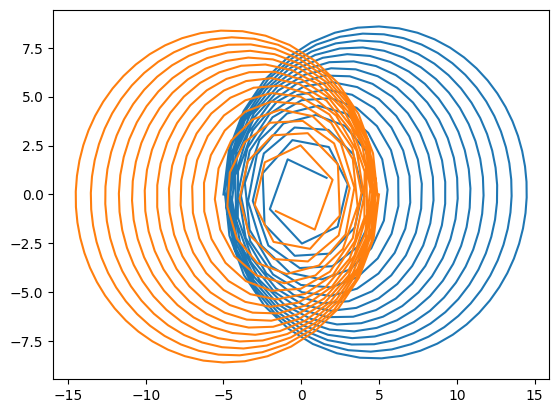

In [73]:
plt.plot(y[0],y[2])
plt.plot(y[6],y[8])

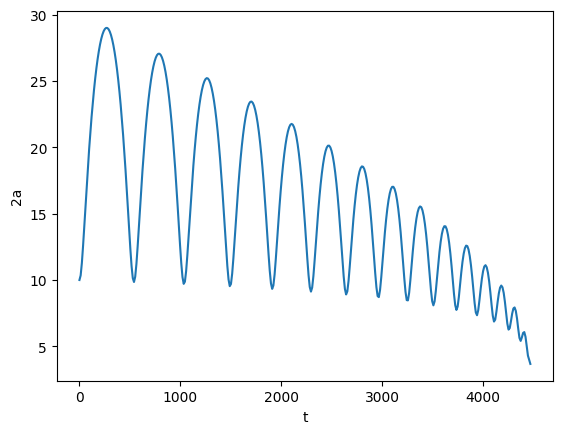

In [74]:
r12=np.sqrt((y[0]-y[6])**2+(y[2]-y[8])**2+(y[4]-y[10])**2)
plt.plot(t,r12)
plt.xlabel('t')
plt.ylabel('2a');

In [75]:
r12=np.sqrt((y[0]-y[6])**2+(y[2]-y[8])**2+(y[4]-y[10])**2)
v12=np.sqrt((y[1]-y[7])**2+(y[3]-y[9])**2+(y[5]-y[11])**2)

In [76]:
def eps(y):
    r12=np.sqrt((y[0]-y[6])**2+(y[2]-y[8])**2+(y[4]-y[10])**2)
    v12=np.sqrt((y[1]-y[7])**2+(y[3]-y[9])**2+(y[5]-y[11])**2)
    return v12**2/2-G*M/r12

Text(0, 0.5, '$\\epsilon$')

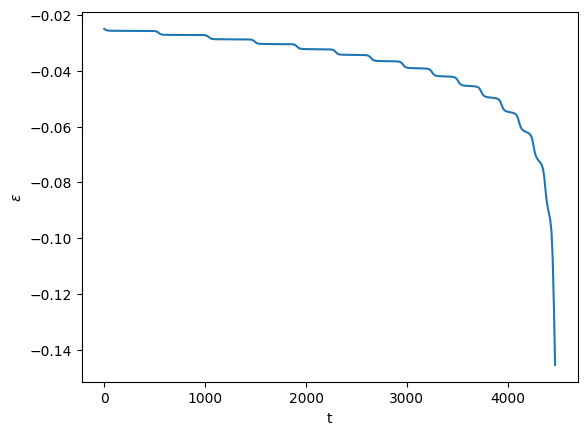

In [77]:
plt.plot(t,eps(y))
plt.xlabel("t")
plt.ylabel(r'$\epsilon$')

In [78]:
a=-G*M/(2*eps(y))

(373, 3)
(373,)


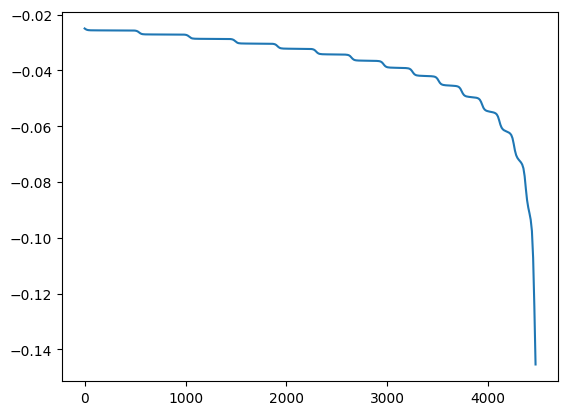

In [79]:
r12=np.sqrt((y[0]-y[6])**2+(y[2]-y[8])**2+(y[4]-y[10])**2).T
r=np.array([y[0]-y[6], y[2]-y[8], y[4]-y[10]]).T
print(np.shape(r))
v12=np.sqrt((y[1]-y[7])**2+(y[3]-y[9])**2+(y[5]-y[11])**2).T
v=np.array([y[1]-y[7], y[3]-y[9], y[5]-y[11]]).T

eps=v12**2/2-G*(m1+m2)/r12

a=-G*(m1+m2)/(2*eps)

harray=np.array([])

for i in range(len(t)):
    h=np.cross(r[i,:],v[i,:])
    h2=np.dot(h,h)
    harray=np.append(harray,h2)

print(np.shape(harray))

e=np.sqrt(1-harray/(G*(m1+m2)*a))

plt.plot(t, eps)

# PART 2

In [80]:
def fe(e):
    return (1+73/24*e**2+37/96*e**4)/(1-e**2)**(7/2)

def ge(e):
    return (1+121/304*e**2)/(1-e**2)**(5/2)

def Peter(t,y):
    e, a = y[1], y[0]
    dera=-64/5*G**3*m1*m2*M/c**5/a**3 * fe(e)
    dere=(-304/15*e*G**3*m1*m2*M)/(c**5*a**4)*ge(e)
    dery=[0,0]
    dery[0]=dera
    dery[1]=dere
    return dery

In [84]:
isco.terminal = True
isco.direction = -1

a0=20
e0=0.5
y0=[a0,e0]

sol=scipy.integrate.solve_ivp(Peter,t_span,y0,method='RK45',t_eval=t_eval, rtol=1e-10,atol=1e-10)#, #events=isco

In [85]:
t_new=sol['t']
y_new=sol['y']

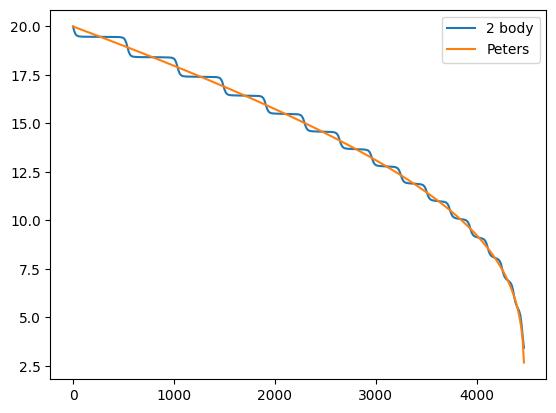

In [87]:
plt.plot(t,a, label="2 body")
plt.plot(t_new,y_new[0], label="Peters")
plt.legend()

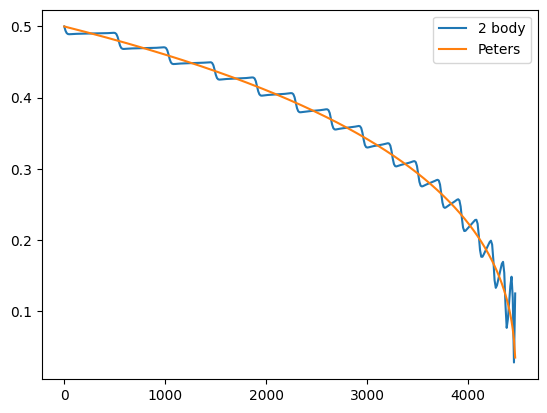

In [89]:
plt.plot(t,e, label="2 body")
plt.plot(t_new,y_new[1], label="Peters")
plt.legend()

# Part 3

In [173]:
def acc(y):
    r1=np.array([y[0],y[2],y[4]])
    r2=np.array([y[6],y[8],y[10]])

    vec_r12=r1-r2
    r12=np.sqrt(np.dot(vec_r12,vec_r12))
    
    n12=vec_r12/r12

    v1=np.array([y[1],y[3],y[5]])
    v2=np.array([y[7],y[9],y[11]])

    vec_v12=v1-v2
    v12=np.sqrt(np.dot(vec_v12,vec_v12))

    nv12=vec_v12/v12

    #T1=(208*G**3*m1*m2**2) / (15*r12**4) *np.dot(n12,vec_v12)
    #T2=-(24*G**3*m1**2*m2) / (5*r12**4) *np.dot(n12,vec_v12)
    
    a1=-G*m2/r12**2*n12 + 1/c**5*( ( (208*G**3*m1*m2**2) / (15*r12**4) *np.dot(n12,vec_v12) - (24*G**3*m1**2*m2) / (5*r12**4) *np.dot(n12,vec_v12) + (12*G**2*m1*m2) / (5*r12**3) *np.dot(n12,vec_v12) *v12**2 ) *n12 + ( (8*G**3*m1**2*m2) / (5*r12**4) - (32*G**3*m1*m2**2) / (5*r12**4) - (4*G**2*m1*m2) / (5*r12**3) *v12**2) * vec_v12)

    n12=-n12
    v12=-v12
    vec_v12=-vec_v12

    a2=-G*m2/r12**2*n12 + 1/c**5*( ( (208*G**3*m1*m2**2) / (15*r12**4) *np.dot(n12,vec_v12) - (24*G**3*m1**2*m2) / (5*r12**4) *np.dot(n12,vec_v12) + (12*G**2*m1*m2) / (5*r12**3) *np.dot(n12,vec_v12) *v12**2 ) *n12 + ( (8*G**3*m1**2*m2) / (5*r12**4) - (32*G**3*m1*m2**2) / (5*r12**4) - (4*G**2*m1*m2) / (5*r12**3) *v12**2) * vec_v12)

    return np.array([a1,a2])    

In [177]:
def I(t,y):

    r1=np.array([y[0],y[2],y[4]])
    r2=np.array([y[6],y[8],y[10]])
    v1=np.array([y[1],y[3],y[5]])
    v2=np.array([y[7],y[9],y[11]])
    a1=np.zeros(shape=(3,len(t)))
    a2=np.zeros(shape=(3,len(t)))
    
    for k in range(len(t)):
        a1[:,k] = acc(y[:,k])[0]
        a2[:,k] = acc(y[:,k])[1]

    I_dotdot=np.zeros(shape=(len(t),3,3))
    for i in range(3):
        for j in range(3):
                I_dotdot[:,i,j]=m1*(a1[i]*r1[j]+2*v1[i]*v1[j]+r1[i]*a1[j])+m2*(a2[i]*r2[j]+2*v2[i]*v2[j]+r2[i]*a2[j])

    return I_dotdot

In [182]:
Q=I(t,y) #it's Q dot dot
print(np.shape(Q))

(373, 3, 3)


In [183]:
R=100

#h_plus=G/c**4/R * (Q[:,0,0] - Q[:,1,1])
#h_cross=2*G/c**4/R * Q[:,0,1]

#h_strength=np.array(h_plus,h_cross)

theta=np.pi/6
phi=np.pi/6

n=np.array([np.cos(phi)*np.sin(theta),np.sin(phi)*np.sin(theta),np.cos(theta)])
